 MOBILE PRICE CLASSIFICATION USING KNN

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

SECTION 1: Install Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from google.colab import files

SECTION 3: Load Dataset

In [4]:
print("Upload the CSV file")
uploaded = files.upload()
data = pd.read_csv("mobile_price_dataset.csv")
print("Dataset Loaded Successfully!")
print("First 5 rows:")
print(data.head())


Upload the CSV file


Saving mobile_price_dataset.csv to mobile_price_dataset.csv
Dataset Loaded Successfully!
First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3    

SECTION 4: Explore Dataset

In [5]:
print("\nDataset Info:")
print(data.info())

print("\nSummary Statistics:")
print(data.describe())

print("\nMissing Values Check:")
print(data.isnull().sum())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Summary Statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523

SECTION 5: Visualize Dataset

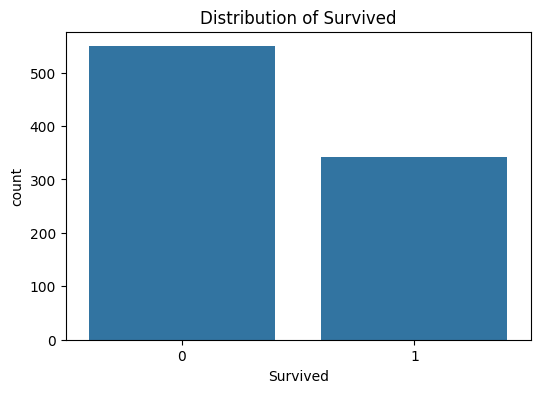

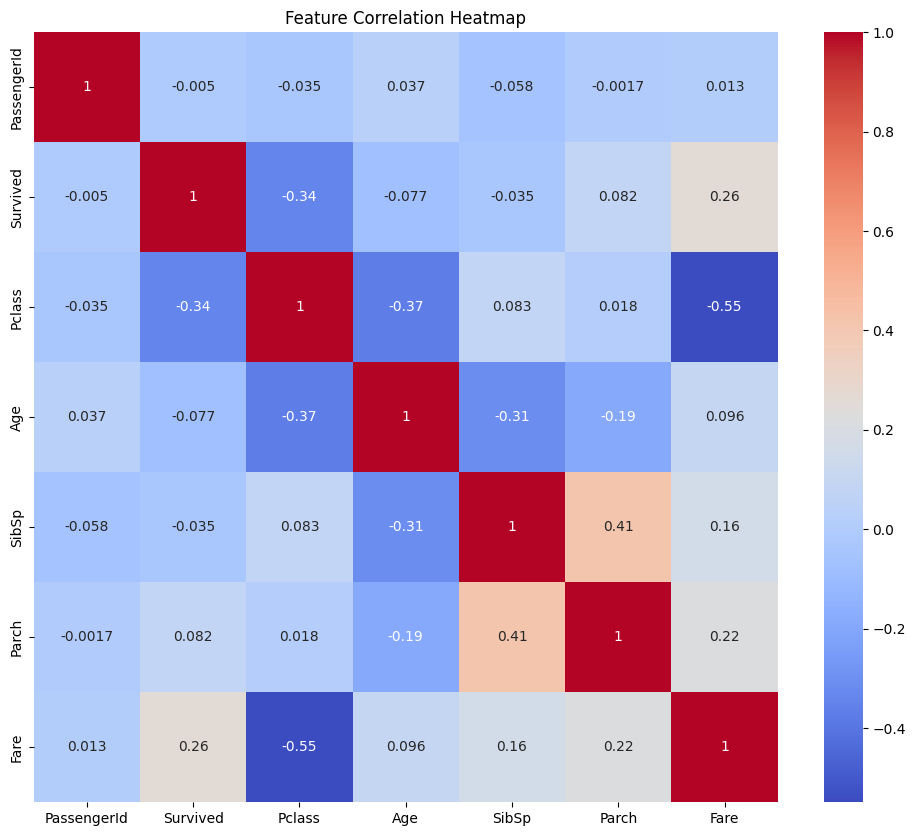

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=data)
plt.title("Distribution of Survived")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

 SECTION 6: Split Features and Target

In [9]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

print("\nFeatures:", X.columns)
print("Target classes:", y.unique())


Features: Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Target classes: [0 1]


SECTION 7: Data Preprocessing

In [10]:
# Impute missing values
X['Age'].fillna(X['Age'].median(), inplace=True)
X['Embarked'].fillna(X['Embarked'].mode()[0], inplace=True)

# Encode 'Sex'
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})

# One-hot encode 'Embarked'
X = pd.get_dummies(X, columns=['Embarked'], drop_first=True, dtype=int)

# Drop irrelevant columns
X = X.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

print("\nProcessed Features (X) Info:")
print(X.info())
print("\nFirst 5 rows of processed X:")
print(X.head())


Processed Features (X) Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Sex         891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Embarked_Q  891 non-null    int64  
 7   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB
None

First 5 rows of processed X:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0       3    0  22.0      1      0   7.2500           0           1
1       1    1  38.0      1      0  71.2833           0           0
2       3    1  26.0      0      0   7.9250           0           1
3       1    1  35.0      1      0  53.1000           0           1
4       3    0  35.0      0   

/tmp/ipykernel_244/894935668.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)
/tmp/ipykernel_244/894935668.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

SECTION 8: Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training and Testing Sets Created")
print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)

Training and Testing Sets Created
X_train shape: (712, 8) X_test shape: (179, 8)


SECTION 9: Feature Scaling

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features Scaled Successfully")

Features Scaled Successfully


 SECTION 9: Initialize KNN Model

In [16]:
knn = KNeighborsClassifier()
print("KNN Classifier Initialized")

KNN Classifier Initialized


 SECTION 10: Hyperparameter Tuning

In [18]:
param_grid = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform','distance'],
    'metric': ['euclidean','manhattan']
}

grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

best_knn = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}


 SECTION 11: Train Best KNN Model

In [19]:
best_knn.fit(X_train_scaled, y_train)
print("KNN Model Trained Successfully")

KNN Model Trained Successfully


 SECTION 12: Evaluate Model

Predictions Completed
KNN Accuracy Score: 0.7988826815642458

Confusion Matrix:
[[97 13]
 [23 46]]


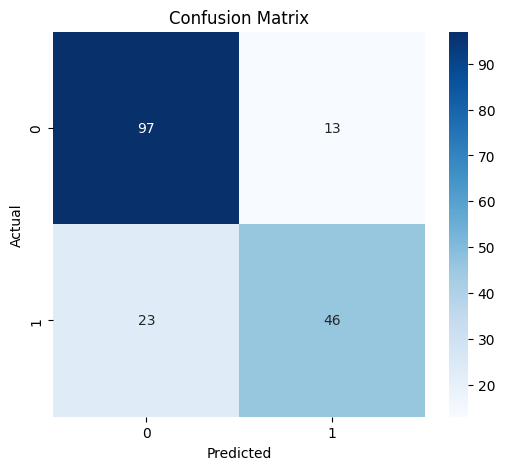


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       110
           1       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



In [24]:
y_pred = best_knn.predict(X_test_scaled)
print("Predictions Completed")

accuracy = accuracy_score(y_test, y_pred)
print("KNN Accuracy Score:", accuracy)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

SECTION 13: Sample Predictions

In [26]:
sample_index = np.random.choice(len(X_test_scaled), 5, replace=False)
sample_data = X_test_scaled[sample_index]
sample_actual = y_test.iloc[sample_index]
sample_pred = best_knn.predict(sample_data)

print("Sample Predictions:")
for i in range(len(sample_index)):
    print(f"Actual: {sample_actual.iloc[i]}, Predicted: {sample_pred[i]}")

Sample Predictions:
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 1
Actual: 1, Predicted: 0
Actual: 1, Predicted: 1


 SECTION 14: Model Ready

In [27]:
print("KNN Mobile Price Classification Model is ready for deployment!")

KNN Mobile Price Classification Model is ready for deployment!
